##Task1

###SECTION 1 — Install & Import Libraries

In [2]:
!pip install pyarrow fastparquet statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os
import requests
from io import BytesIO

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.filters.hp_filter import hpfilter

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

print("Libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.8 MB/s eta 0:00:00
Libraries loaded successfully.


###SECTION 2 — Download Yellow Taxi Parquet Files from NYC TLC

In [3]:
YEARS  = [2023, 2024, 2025]
MONTHS = {
    2023: range(1, 13),   # Jan–Dec
    2024: range(1, 13),   # Jan–Dec
    2025: range(1, 12),   # Jan–Nov (12 = Dec not yet available)
}

BASE_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data"
SAVE_DIR  = "/content/yellow_taxi_raw"      # change if using Drive
os.makedirs(SAVE_DIR, exist_ok=True)

# Columns we need — requesting only these saves memory in Colab
COLS_NEEDED = [
    "tpep_pickup_datetime",
    "fare_amount",
    "total_amount",
    "trip_distance",
    "passenger_count",
    "payment_type",
]

def download_month(year, month):
    fname = f"yellow_tripdata_{year}-{month:02d}.parquet"
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        print(f"  [cached] {fname}")
        return fpath
    url = f"{BASE_URL}/{fname}"
    print(f"  Downloading {fname} ...", end=" ")
    r = requests.get(url, timeout=120)
    if r.status_code == 200:
        with open(fpath, "wb") as f:
            f.write(r.content)
        print(f"done ({len(r.content)/1e6:.1f} MB)")
    else:
        print(f"FAILED (HTTP {r.status_code})")
        return None
    return fpath

all_paths = []
for year in YEARS:
    print(f"\n--- {year} ---")
    for month in MONTHS[year]:
        path = download_month(year, month)
        if path:
            all_paths.append(path)

print(f"\nTotal files ready: {len(all_paths)}")


--- 2023 ---

--- 2024 ---

--- 2025 ---

Total files ready: 35


###SECTION 3 — Load, Filter & Concatenate

In [4]:
def load_and_filter(fpath):
    """Load one parquet file, keep only needed columns, apply basic filters."""
    df = pd.read_parquet(fpath, columns=COLS_NEEDED)

    # Parse datetime
    df["pickup_date"] = pd.to_datetime(
        df["tpep_pickup_datetime"], errors="coerce"
    ).dt.normalize()

    # Drop rows with unparseable dates
    df = df.dropna(subset=["pickup_date"])

    # Keep only dates within our study window
    df = df[
        (df["pickup_date"] >= "2023-01-01") &
        (df["pickup_date"] <= "2025-11-30")
    ]

    # ── Hard filters (remove physically impossible values) ──────────────────
    df = df[df["fare_amount"]   > 0]
    df = df[df["fare_amount"]   < 500]    # cap extreme outliers
    df = df[df["total_amount"]  > 0]
    df = df[df["total_amount"]  < 600]
    df = df[df["trip_distance"] >= 0]     # allow 0 (metered waits)
    df = df[df["trip_distance"] < 200]    # cap extreme outliers

    return df[["pickup_date", "fare_amount", "total_amount"]]

print("Loading and filtering all files...")
chunks = []
for i, path in enumerate(all_paths):
    print(f"  [{i+1}/{len(all_paths)}] {os.path.basename(path)}")
    chunk = load_and_filter(path)
    chunks.append(chunk)

raw = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows after filtering: {len(raw):,}")
print(raw.dtypes)

Loading and filtering all files...
  [1/35] yellow_tripdata_2023-01.parquet
  [2/35] yellow_tripdata_2023-02.parquet
  [3/35] yellow_tripdata_2023-03.parquet
  [4/35] yellow_tripdata_2023-04.parquet
  [5/35] yellow_tripdata_2023-05.parquet
  [6/35] yellow_tripdata_2023-06.parquet
  [7/35] yellow_tripdata_2023-07.parquet
  [8/35] yellow_tripdata_2023-08.parquet
  [9/35] yellow_tripdata_2023-09.parquet
  [10/35] yellow_tripdata_2023-10.parquet
  [11/35] yellow_tripdata_2023-11.parquet
  [12/35] yellow_tripdata_2023-12.parquet
  [13/35] yellow_tripdata_2024-01.parquet
  [14/35] yellow_tripdata_2024-02.parquet
  [15/35] yellow_tripdata_2024-03.parquet
  [16/35] yellow_tripdata_2024-04.parquet
  [17/35] yellow_tripdata_2024-05.parquet
  [18/35] yellow_tripdata_2024-06.parquet
  [19/35] yellow_tripdata_2024-07.parquet
  [20/35] yellow_tripdata_2024-08.parquet
  [21/35] yellow_tripdata_2024-09.parquet
  [22/35] yellow_tripdata_2024-10.parquet
  [23/35] yellow_tripdata_2024-11.parquet
  [24/35

###SECTION 4 — Daily Aggregation (3 time series)

In [5]:
daily = (
    raw
    .groupby("pickup_date")
    .agg(
        trip_count   = ("fare_amount",   "count"),   # trips per day
        avg_fare     = ("fare_amount",   "mean"),    # avg fare per day
        total_revenue= ("total_amount",  "sum"),     # total revenue per day
    )
    .reset_index()
    .rename(columns={"pickup_date": "date"})
    .sort_values("date")
    .set_index("date")
)

# Ensure complete date range — fill missing days with 0 (structural zeros)
full_idx = pd.date_range("2023-01-01", "2025-11-30", freq="D")
daily = daily.reindex(full_idx)
daily["trip_count"]    = daily["trip_count"].fillna(0).astype(int)
daily["avg_fare"]      = daily["avg_fare"].fillna(method="ffill")   # carry forward
daily["total_revenue"] = daily["total_revenue"].fillna(0)
daily.index.name = "date"

print("\nDaily aggregated series shape:", daily.shape)
print(daily.head(10))
print(daily.describe())


Daily aggregated series shape: (1065, 3)
            trip_count   avg_fare  total_revenue
date                                            
2023-01-01       76007  22.300923     2367177.54
2023-01-02       65058  22.412369     2050189.56
2023-01-03       84964  20.401231     2509794.58
2023-01-04       94263  19.300488     2664244.05
2023-01-05      100217  18.669895     2755189.18
2023-01-06      101690  18.111248     2731732.96
2023-01-07      104090  17.860373     2684427.17
2023-01-08       84309  20.081737     2421499.13
2023-01-09       84577  19.156756     2388760.01
2023-01-10       99124  17.926054     2648885.84
          trip_count     avg_fare  total_revenue
count    1065.000000  1065.000000   1.065000e+03
mean   112609.107981    19.925650   3.240307e+06
std     20111.051907     1.188598   5.901742e+05
min      4615.000000    16.706391   1.325504e+05
25%     99520.000000    19.161061   2.836594e+06
50%    113096.000000    19.970763   3.226378e+06
75%    126663.000000    20.

###SECTION 5 — IQR Outlier Removal on Daily Series

In [6]:
def iqr_clip(series, multiplier=3.0):
    """Winsorise using IQR; less aggressive than dropping to preserve continuity."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    clipped = series.clip(lower=lower, upper=upper)
    n_clipped = (series != clipped).sum()
    print(f"  {series.name}: {n_clipped} days clipped  "
          f"[{lower:,.1f} – {upper:,.1f}]")
    return clipped

print("\nIQR outlier clipping (3×IQR):")
daily["trip_count"]    = iqr_clip(daily["trip_count"])
daily["avg_fare"]      = iqr_clip(daily["avg_fare"])
daily["total_revenue"] = iqr_clip(daily["total_revenue"])


IQR outlier clipping (3×IQR):
  trip_count: 3 days clipped  [18,091.0 – 208,092.0]
  avg_fare: 0 days clipped  [14.6 – 25.3]
  total_revenue: 3 days clipped  [458,606.8 – 6,007,244.2]


###SECTION 6 — Weekly Resampling

In [7]:
# Weekly aggregation smooths day-of-week noise; better for seasonal decomp

weekly = daily.resample("W").agg(
    trip_count    = ("trip_count",    "sum"),
    avg_fare      = ("avg_fare",      "mean"),
    total_revenue = ("total_revenue", "sum"),
)

print("\nWeekly series shape:", weekly.shape)
print(weekly.head())


Weekly series shape: (153, 3)
            trip_count   avg_fare  total_revenue
date                                            
2023-01-01       76007  22.300923     2367177.54
2023-01-08      634591  19.548191    17817076.63
2023-01-15      717216  18.516054    19582636.91
2023-01-22      706968  18.660539    19323171.43
2023-01-29      723026  18.088665    19347389.55


###SECTION 7 — Plot Raw Daily Series (all 3 variables)

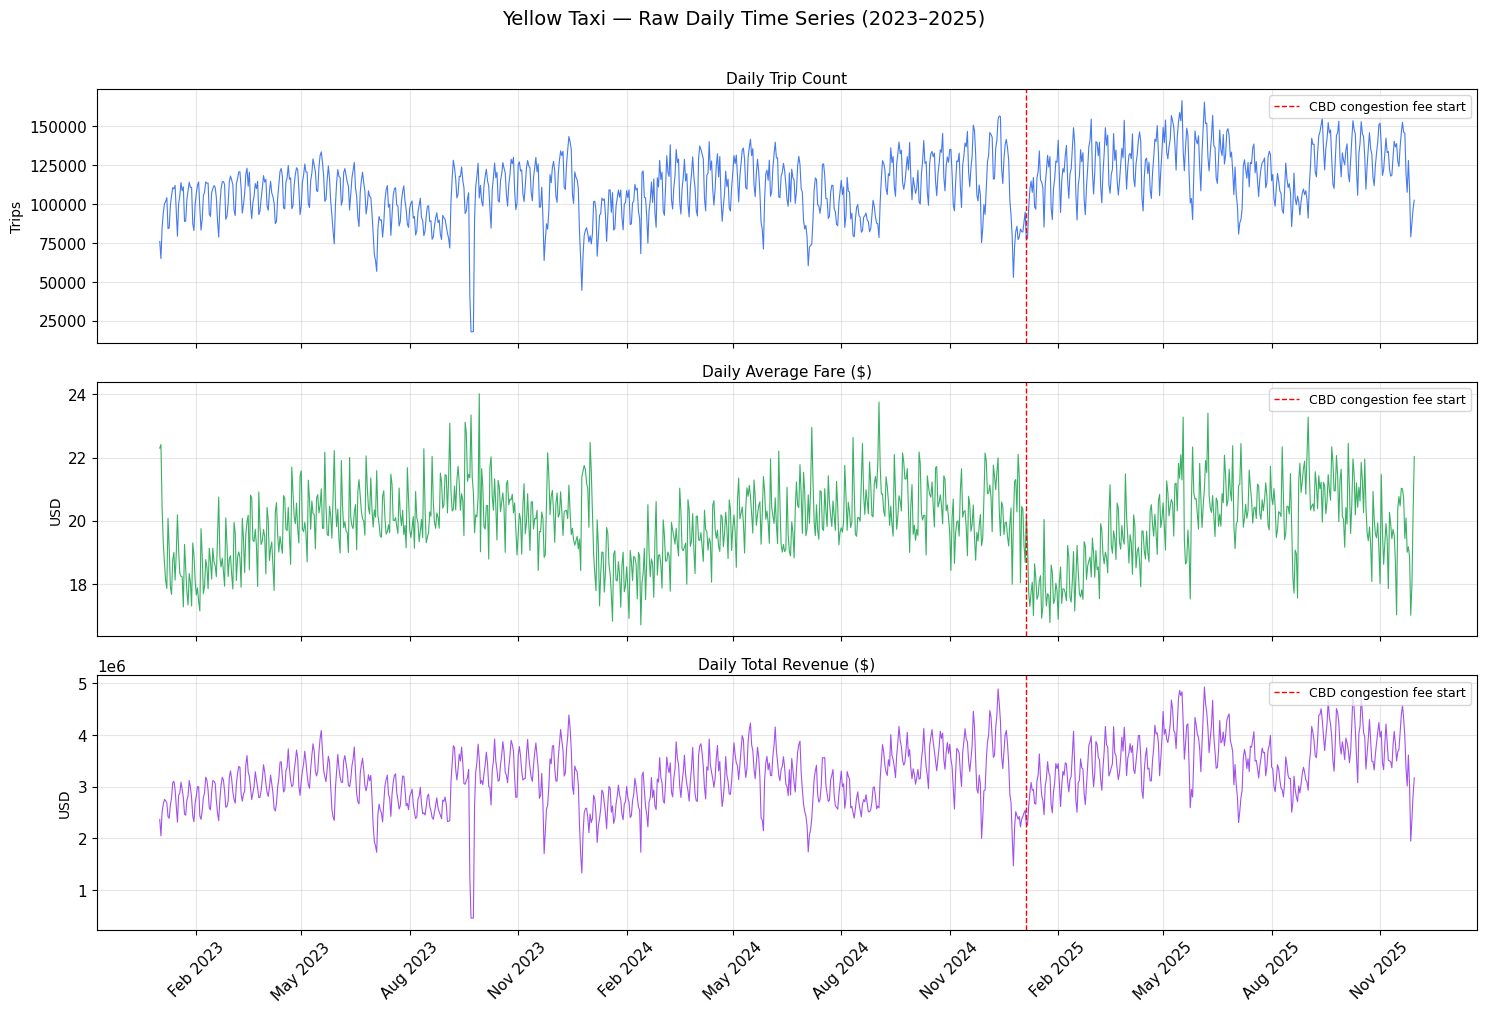

Saved: 01_raw_daily_series.png


In [8]:
VARIABLES = {
    "trip_count":    ("Daily Trip Count",          "Trips",   "#2563EB"),
    "avg_fare":      ("Daily Average Fare ($)",     "USD",     "#16A34A"),
    "total_revenue": ("Daily Total Revenue ($)",    "USD",     "#9333EA"),
}

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle("Yellow Taxi — Raw Daily Time Series (2023–2025)", fontsize=14, y=1.01)

for ax, (col, (title, ylabel, color)) in zip(axes, VARIABLES.items()):
    ax.plot(daily.index, daily[col], color=color, linewidth=0.8, alpha=0.85)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, pad=4)
    # Mark congestion fee start (Jan 5, 2025 — structural break)
    ax.axvline(pd.Timestamp("2025-01-05"), color="red",
               linestyle="--", linewidth=1, label="CBD congestion fee start")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/01_raw_daily_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_raw_daily_series.png")

###SECTION 8 — STL Decomposition (additive & multiplicative)


Daily Trip Count:
  Additive residual var  : 95042258.6389
  Multiplicative resid var: 0.0160
  → Better fit: Multiplicative (log)


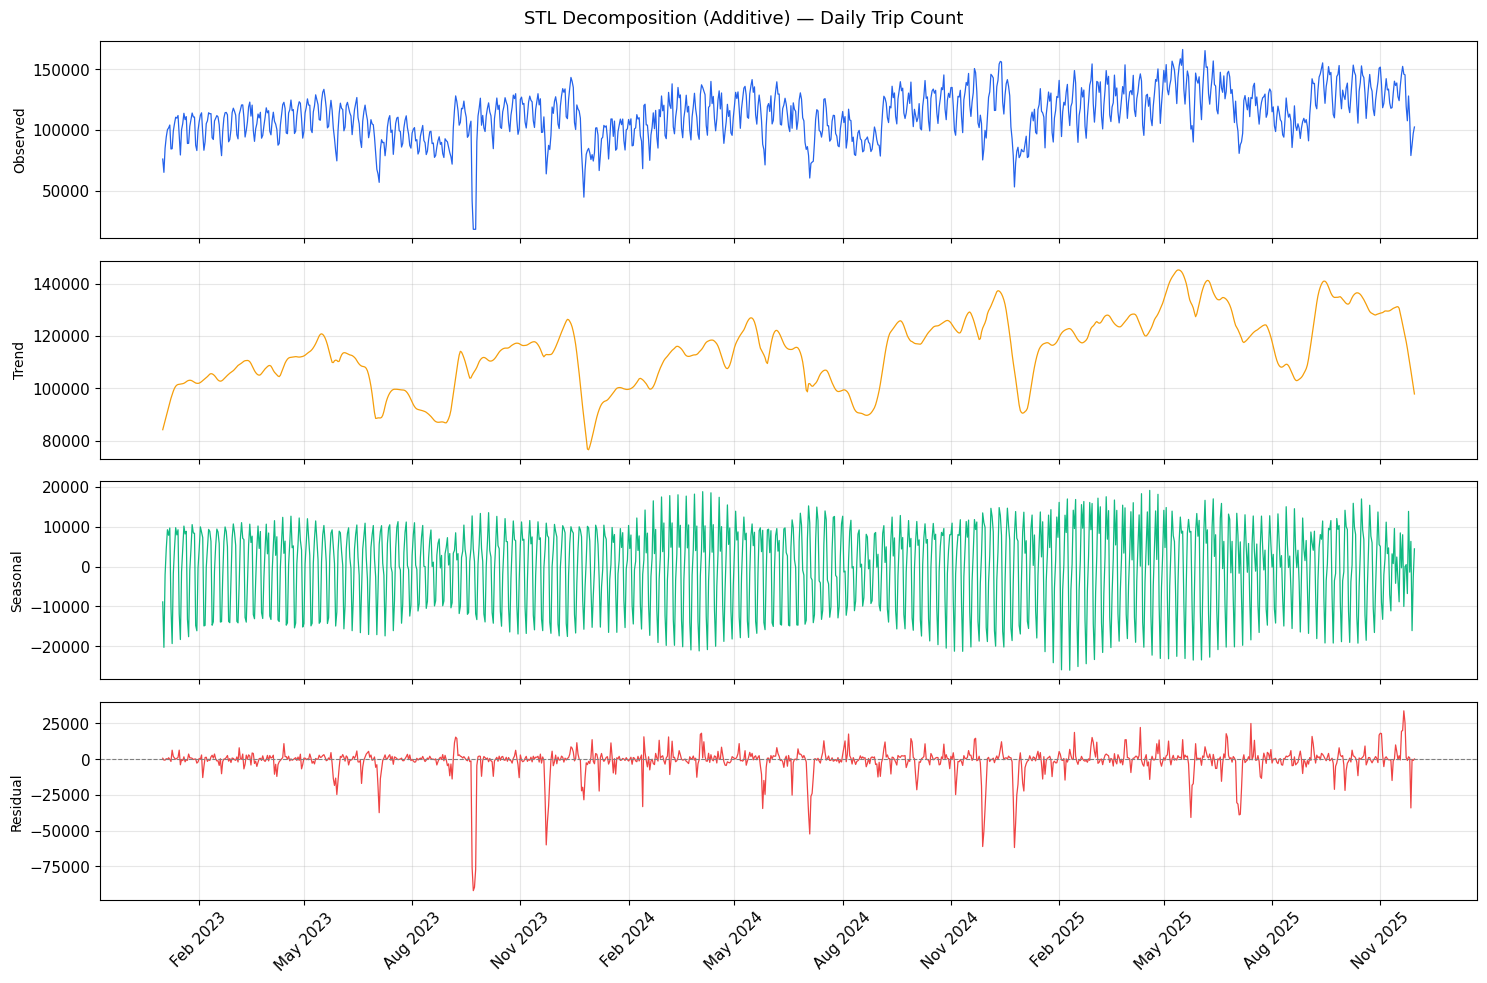

  Saved: /content/02_stl_daily_trip_count.png

Daily Average Fare ($):
  Additive residual var  : 0.3280
  Multiplicative resid var: 0.0007
  → Better fit: Multiplicative (log)


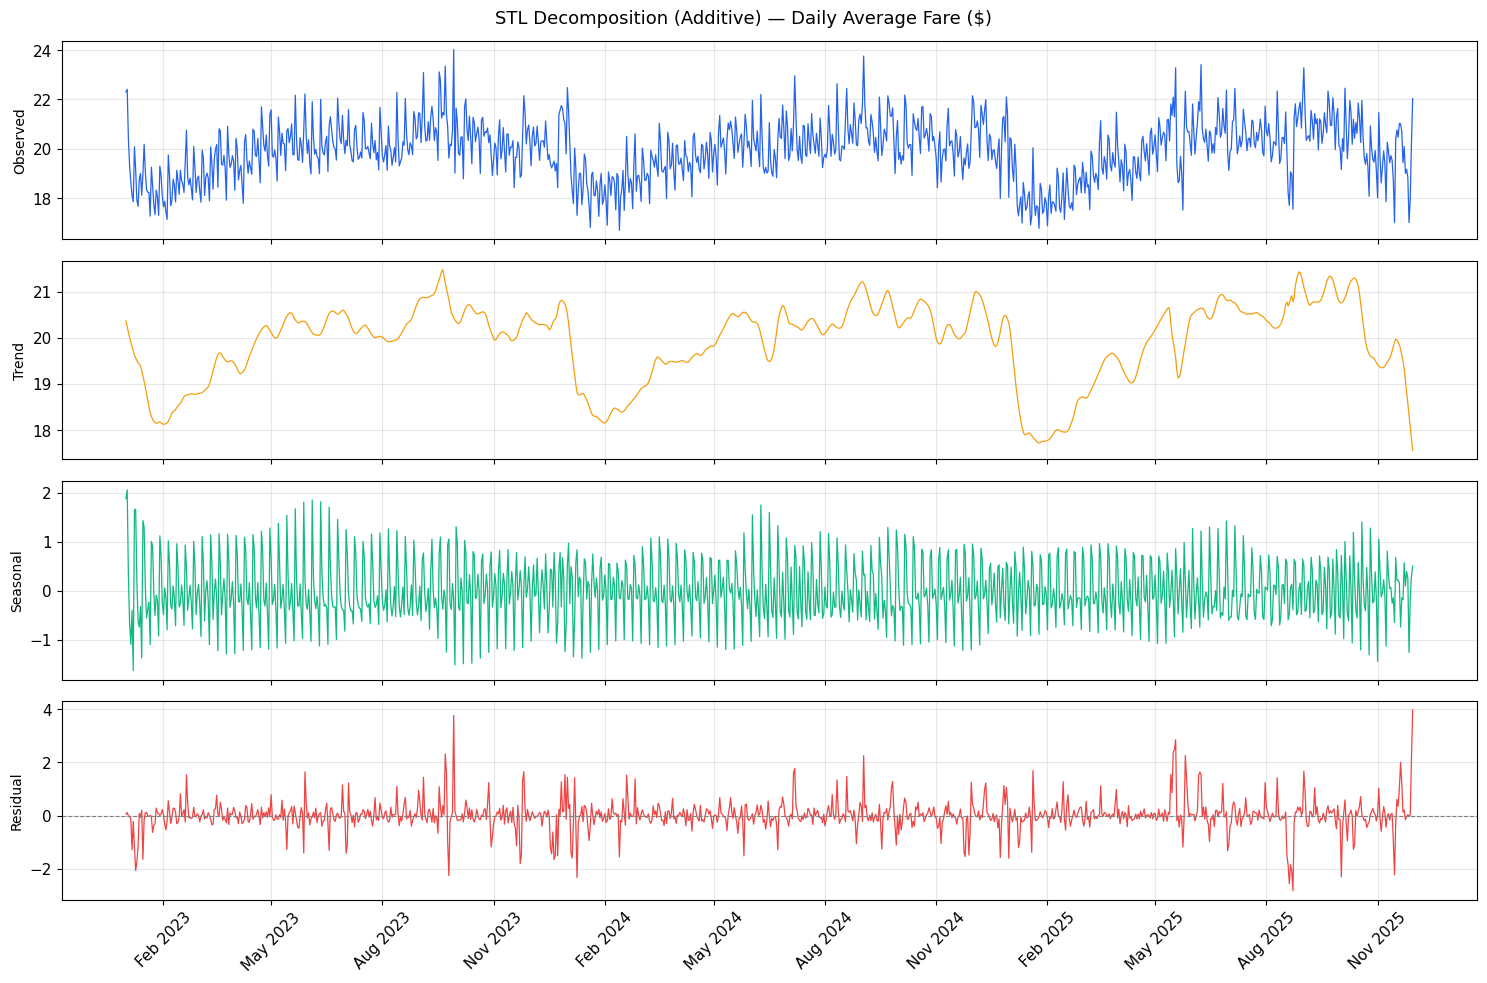

  Saved: /content/02_stl_daily_average_fare_($).png

Daily Total Revenue ($):
  Additive residual var  : 91231845456.9656
  Multiplicative resid var: 0.0190
  → Better fit: Multiplicative (log)


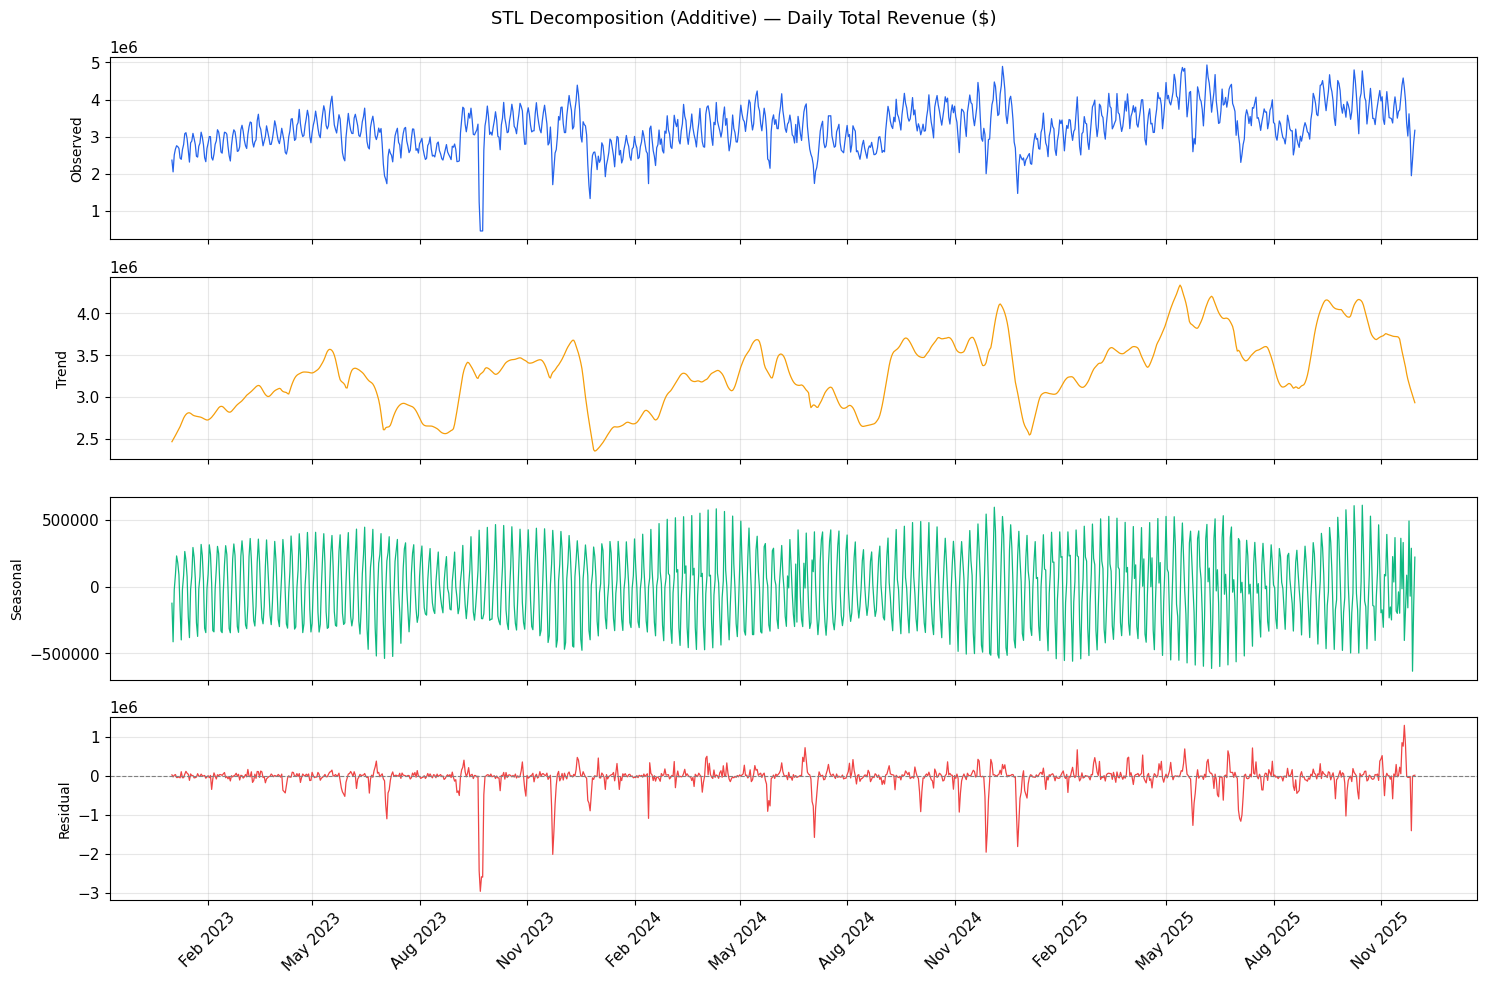

  Saved: /content/02_stl_daily_total_revenue_($).png


In [9]:
# Period = 7 for daily data (weekly seasonality)
# We compare additive vs multiplicative by checking residual variance

def run_stl(series, label, period=7):
    """Run STL decomposition and return the result object."""
    # STL works best on additive; for multiplicative we log-transform
    stl_add  = STL(series,              period=period, robust=True).fit()
    stl_mult = STL(np.log1p(series),    period=period, robust=True).fit()

    resid_var_add  = np.var(stl_add.resid)
    resid_var_mult = np.var(stl_mult.resid)
    better = "Additive" if resid_var_add <= resid_var_mult else "Multiplicative (log)"
    print(f"\n{label}:")
    print(f"  Additive residual var  : {resid_var_add:.4f}")
    print(f"  Multiplicative resid var: {resid_var_mult:.4f}")
    print(f"  → Better fit: {better}")

    # Plot additive decomposition
    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
    fig.suptitle(f"STL Decomposition (Additive) — {label}", fontsize=13)
    components = {
        "Observed":  stl_add.observed,
        "Trend":     stl_add.trend,
        "Seasonal":  stl_add.seasonal,
        "Residual":  stl_add.resid,
    }
    colors = ["#2563EB", "#F59E0B", "#10B981", "#EF4444"]
    for ax, (comp_name, comp_data), color in zip(axes, components.items(), colors):
        ax.plot(series.index, comp_data, color=color, linewidth=0.9)
        ax.set_ylabel(comp_name, fontsize=10)
        if comp_name == "Residual":
            ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    fname = f"/content/02_stl_{label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    return stl_add

stl_results = {}
for col, (title, _, _) in VARIABLES.items():
    stl_results[col] = run_stl(daily[col], title)

###SECTION 9 — Detrending

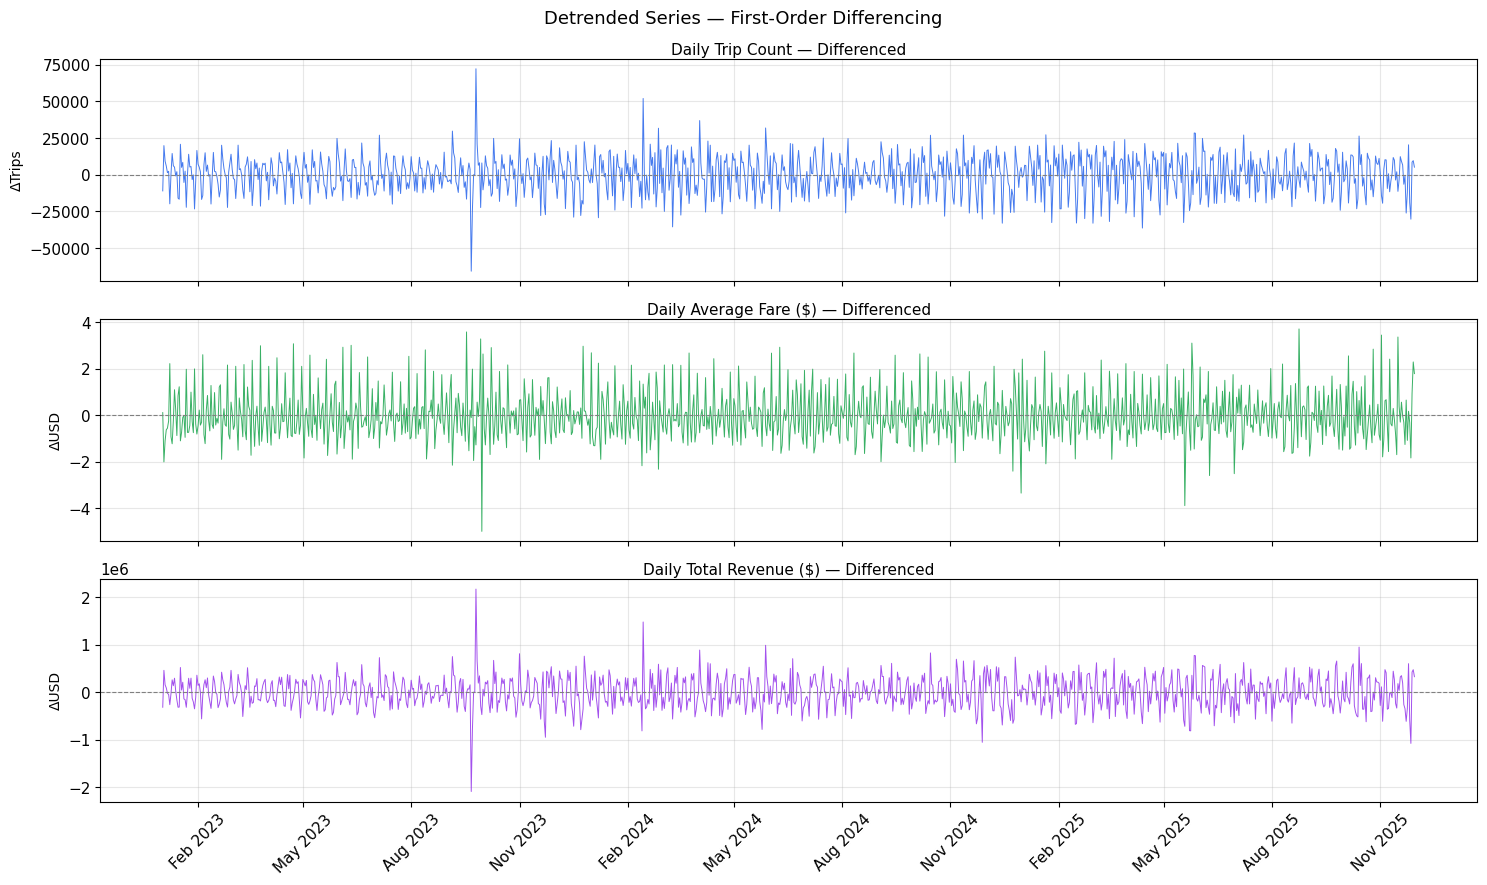

Saved: 03_detrended_diff1.png


In [10]:
# Method A: First-order differencing  (removes linear/stochastic trends)
# Method B: Hodrick-Prescott filter   (extracts smooth trend, keeps cycle)

detrended = pd.DataFrame(index=daily.index)

for col in VARIABLES:
    series = daily[col].copy()

    # ── Method A: First-difference ──────────────────────────────────────────
    detrended[f"{col}_diff1"] = series.diff(1)

    # ── Method B: HP filter ─────────────────────────────────────────────────
    # lambda=1600 standard for quarterly; for daily data use 129600
    cycle, trend = hpfilter(series.dropna(), lamb=129600)
    hp_cycle = pd.Series(cycle, index=series.dropna().index)
    hp_cycle = hp_cycle.reindex(daily.index)
    detrended[f"{col}_hp_cycle"] = hp_cycle
    detrended[f"{col}_hp_trend"] = pd.Series(
        hpfilter(series.dropna(), lamb=129600)[1],
        index=series.dropna().index
    ).reindex(daily.index)

# Plot detrended series (first-difference) for all 3 variables
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
fig.suptitle("Detrended Series — First-Order Differencing", fontsize=13)
for ax, (col, (title, ylabel, color)) in zip(axes, VARIABLES.items()):
    ax.plot(daily.index, detrended[f"{col}_diff1"],
            color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_ylabel(f"Δ{ylabel}", fontsize=10)
    ax.set_title(f"{title} — Differenced", fontsize=11, pad=3)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/03_detrended_diff1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_detrended_diff1.png")

###SECTION 10 — Deseasonalization (Seasonal Differencing)

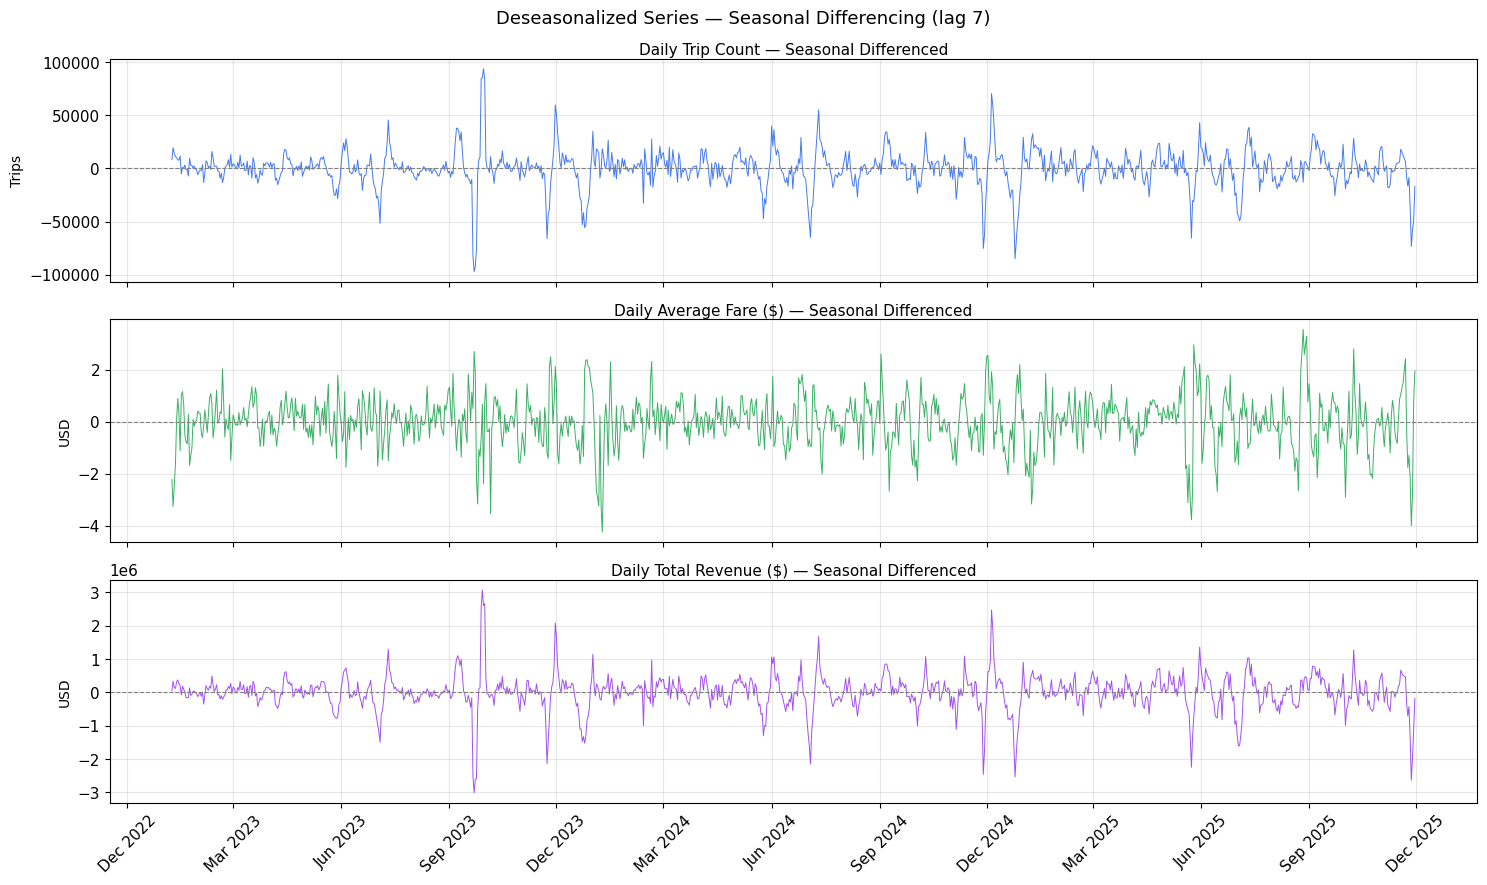

Saved: 04_deseasonalized.png


In [11]:
# Lag = 7 removes weekly seasonality from daily series

deseasoned = pd.DataFrame(index=daily.index)

for col in VARIABLES:
    # Seasonal differencing: x(t) - x(t-7)
    deseasoned[f"{col}_seas_diff7"] = daily[col].diff(7)

    # Alternatively: subtract STL seasonal component
    stl_seasonal = stl_results[col].seasonal
    deseasoned[f"{col}_stl_deseas"] = daily[col] - stl_seasonal

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
fig.suptitle("Deseasonalized Series — Seasonal Differencing (lag 7)", fontsize=13)
for ax, (col, (title, ylabel, color)) in zip(axes, VARIABLES.items()):
    ax.plot(daily.index, deseasoned[f"{col}_seas_diff7"],
            color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f"{title} — Seasonal Differenced", fontsize=11, pad=3)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/04_deseasonalized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_deseasonalized.png")

###SECTION 11 — Train / Test Split


── Train / Holdout Split ─────────────────────────────
  Train   : 2023-01-01 → 2025-09-30 (1004 days)
  Holdout : 2025-10-01 → 2025-11-30 (61 days)


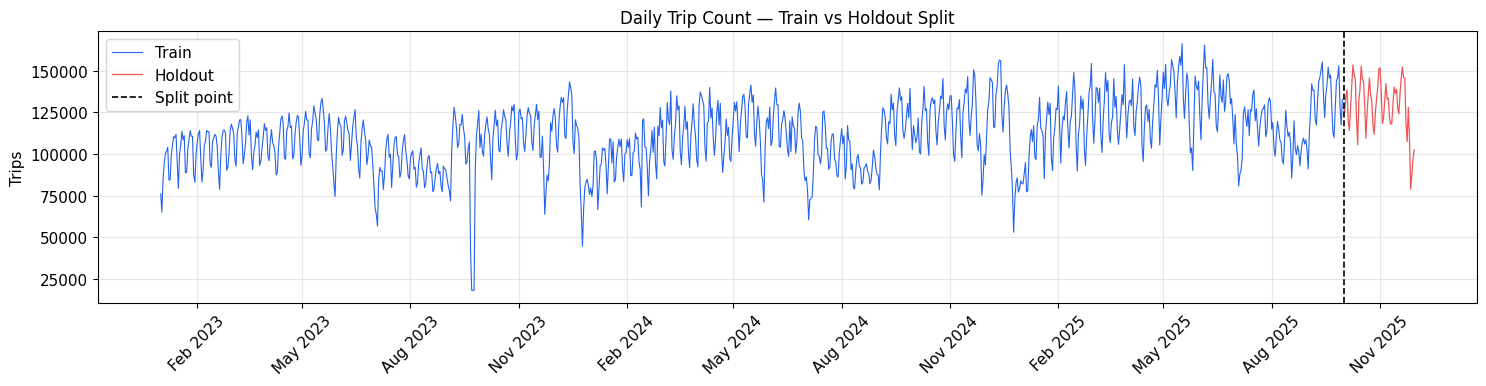

Saved: 05_train_holdout_split.png


In [12]:
# Train: 2023-01-01 – 2025-09-30
# Holdout: 2025-10-01 – 2025-11-30

TRAIN_END   = "2025-09-30"
HOLDOUT_START = "2025-10-01"

train   = daily[daily.index <= TRAIN_END]
holdout = daily[daily.index >= HOLDOUT_START]

print("\n── Train / Holdout Split ─────────────────────────────")
print(f"  Train   : {train.index[0].date()} → {train.index[-1].date()} "
      f"({len(train)} days)")
print(f"  Holdout : {holdout.index[0].date()} → {holdout.index[-1].date()} "
      f"({len(holdout)} days)")

# Visual confirmation of split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train.index,   train["trip_count"],   color="#2563EB",
        linewidth=0.8, label="Train")
ax.plot(holdout.index, holdout["trip_count"], color="#EF4444",
        linewidth=0.9, label="Holdout", alpha=0.9)
ax.axvline(pd.Timestamp(HOLDOUT_START), color="black",
           linestyle="--", linewidth=1.2, label="Split point")
ax.set_title("Daily Trip Count — Train vs Holdout Split", fontsize=12)
ax.set_ylabel("Trips")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/05_train_holdout_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_train_holdout_split.png")

###SECTION 12 — Save Processed Data


In [13]:
daily.to_csv("/content/yellow_taxi_daily.csv")
weekly.to_csv("/content/yellow_taxi_weekly.csv")
detrended.to_csv("/content/yellow_taxi_detrended.csv")
deseasoned.to_csv("/content/yellow_taxi_deseasoned.csv")
train.to_csv("/content/yellow_taxi_train.csv")
holdout.to_csv("/content/yellow_taxi_holdout.csv")

print("\n── All files saved ──────────────────────────────────")
print("  yellow_taxi_daily.csv          → raw daily aggregation")
print("  yellow_taxi_weekly.csv         → weekly resampled")
print("  yellow_taxi_detrended.csv      → diff1 + HP cycle/trend")
print("  yellow_taxi_deseasoned.csv     → seasonal diff (lag 7) + STL deseas")
print("  yellow_taxi_train.csv          → train set (Jan 2023 – Sep 2025)")
print("  yellow_taxi_holdout.csv        → holdout set (Oct–Nov 2025)")
print("\nTask 1 complete. Proceed to Task 2 for stationarity & ACF/PACF analysis.")


── All files saved ──────────────────────────────────
  yellow_taxi_daily.csv          → raw daily aggregation
  yellow_taxi_weekly.csv         → weekly resampled
  yellow_taxi_detrended.csv      → diff1 + HP cycle/trend
  yellow_taxi_deseasoned.csv     → seasonal diff (lag 7) + STL deseas
  yellow_taxi_train.csv          → train set (Jan 2023 – Sep 2025)
  yellow_taxi_holdout.csv        → holdout set (Oct–Nov 2025)

Task 1 complete. Proceed to Task 2 for stationarity & ACF/PACF analysis.
